In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


from utils.data_processing import (
    filter_microbes_by_prevalence,
    transform_counts_data,
    process_string,
)

### Loading Metadata and Counts Data

In [2]:
meta = pd.read_csv("../../data/fay_meta_diets.csv", index_col=0)

In [3]:
path_counts_data = "../../qiime/table_rarefied.tsv"
counts_data = pd.read_csv(path_counts_data, sep="\t", index_col=0, skiprows=1)

# counts_data.index = counts_data.index.map(lambda i: otuID_taxonomy.loc[i].values[0].replace("; ",";")) ## rename ASV id to taxon
# counts_data = counts_data.groupby(counts_data.index).sum() ## sum over ASVs with same taxon
counts_data = counts_data.T

counts_data.index.name = "sample-id"

transformed_counts_data = transform_counts_data(counts_data, method="clr")

print(transformed_counts_data.shape)
transformed_counts_data.head()

(992, 12518)


#OTU ID,8937656c16c20701c107e715bad86732,59196a586276f0be745d0e334fc071c6,ad52a0f6646c574417ce0b13b84acfa9,877f27b47c85f6b2d3cf8a6aa86def40,6c7fa77831ae630967a6fbfc8ee47901,f7686a74ca2d3729eb66305e8a26309b,149e7d5e484d157f2ac6140a2111618e,d061a99148d649c4eca4836c5f4b5b68,959d48a11e3b26c9268f0bd1dae6ec40,447b9d6a5c17543a456c597e65b37139,...,e8ef94f9b7b8c1cb5001b1a849d01a0a,f0efa9c8508f32a3aa10311f7dd5db49,ec2340c4a91f1043faf094b25f29ff83,fba0445d13e83396c5352d9361afe105,e0c7c5f7245986a1a04669cba113d2a5,c1eba7376458ac99a6cd37b64f98fbbf,c4ea259e761b45dd1ee4b6adf054ba4c,3095829f9daf397ac86963f336d6f787,3572535b3b200557e458d78fbd3aca13,44e6ec02726d6328dcf67a42a5ddccab
sample-id,,,,,,,,,,,,,,,,,,,,,
sample30489,7.405528,6.803227,6.513438,6.403535,6.394071,6.306339,5.972631,5.846662,5.692968,5.567166,...,-0.053235,-0.053235,-0.053235,-0.053235,-0.053235,-0.053235,-0.053235,-0.053235,-0.053235,-0.053235
sample30706,6.162181,5.898818,6.932141,5.877820,5.576787,5.612002,2.941307,3.934559,6.298204,4.263063,...,-0.054425,-0.054425,-0.054425,-0.054425,-0.054425,-0.054425,-0.054425,-0.054425,-0.054425,-0.054425
sample30666,5.399163,6.123595,5.880751,4.530451,5.296623,5.310609,5.117114,0.628478,5.399163,5.507485,...,-0.064669,-0.064669,-0.064669,-0.064669,-0.064669,-0.064669,-0.064669,-0.064669,-0.064669,-0.064669
sample15977,5.975675,6.602837,-0.052603,3.443904,6.280676,5.464850,-0.052603,4.791584,4.830199,5.220396,...,-0.052603,-0.052603,-0.052603,-0.052603,-0.052603,-0.052603,-0.052603,-0.052603,-0.052603,-0.052603
sample30750,6.065370,5.198712,3.994739,5.436485,3.780329,3.170564,-0.048312,2.590745,5.127838,4.586417,...,-0.048312,-0.048312,-0.048312,-0.048312,-0.048312,-0.048312,-0.048312,-0.048312,-0.048312,-0.048312


### Create Prevalence Data
or Alternatively, use the prevalence data directly in the root data folder

In [4]:
counts_data_filtered, prevalence = filter_microbes_by_prevalence(
    counts_data, count_threshold=0, prevalence_threshold=0.05
)
print(counts_data_filtered.shape)
print(len(prevalence))

(992, 1202)
12518


In [5]:
# prevalence.to_csv("../../data/prevalence_microbes.csv")
# prevalence = pd.read_csv("../../data/prevalence_microbes.csv", index_col=0)

prevalence.head()

#OTU ID
8937656c16c20701c107e715bad86732    0.858871
59196a586276f0be745d0e334fc071c6    0.983871
ad52a0f6646c574417ce0b13b84acfa9    0.740927
877f27b47c85f6b2d3cf8a6aa86def40    0.796371
6c7fa77831ae630967a6fbfc8ee47901    0.986895
dtype: float64

In [6]:
from utils.data_processing import summarize_microbe_foodvar_relationship, otuID_taxonomy
from utils.plotting_functions import (
    generate_ancestry_color_mapping,
    perform_partial_correlations,
)

from utils.plotting_functions import (
    create_polar_plot,
)

## Choose features for correlation analysis
- Option 1: Use all features
- Option 2: Use features with significant correlations from Birdman

#### Option 1: Uncomment to run partial correlations on entire microbiota features


In [7]:
# features_for_Plot = [i for i in meta.columns if "CV_" + i in meta.columns]
# features_for_Plot += ["CV_" + i for i in features_for_Plot]
# print(len(features_for_Plot))

# partialcorr_across_feats_df, corr_across_feats_df = perform_partial_correlations(
#     transformed_counts_data,
#     meta,
#     features_for_Plot,
#     covariates=["age", "bmi"],
#     corr_threshold=0.15,
#     top_n_common=-1,
#     method="spearman",
# )

# # partialcorr_across_feats_df.to_csv("../../data/partial_corr_across_feats.csv")

In [8]:
# partialcorr_across_feats_df = pd.read_csv(
#     "../../data/partial_corr_across_feats.csv", index_col=0
# )
# partialcorr_across_feats_df

### Option 2: Using Birdman Significant Taxa

In [9]:
birdman_significant_taxa = set()
for i in [
    "HEI",
    "fiber_eaten",
    "vegetables_fg_eaten",
    "fast_food_fg_eaten",
    "oils_nuts_fg_eaten",
    "potassium_eaten",
    "meat_fg_eaten",
    "fruits_fg_eaten",
    "bread_fg_eaten",
]:
    birdman_significant_taxa_i = pd.read_csv(
        f"../birdman_analysis/outputs/{i}/results/differential_taxa.tsv",
        sep="\t",
        index_col=0,
    )
    # birdman_significant_taxa_i = pd.read_csv(f"birdman/significant_taxa/{i}_Quartile.csv", index_col=0)
    # birdman_significant_taxa_i.index = birdman_significant_taxa_i.index.map(lambda i: i.split("[")[1][:-1])
    birdman_significant_taxa = birdman_significant_taxa.union(
        set(birdman_significant_taxa_i["Feature"].values)
    )

len(birdman_significant_taxa)

282

## Run Partial Correlations

In [10]:
features_for_correlationPlot = [
    "CV_HEI",
    "vegetables_fg_eaten",
    "CV_fruits_fg_eaten",
    "fast_food_fg_eaten",
    "oils_nuts_fg_eaten",
    "fatty_acids_polyunsaturated_eaten",
    "fiber_eaten",
    "potassium_eaten",
    "HEI",
    "CV_vegetables_fg_eaten",
    "CV_oils_nuts_fg_eaten",
    "fruits_fg_eaten",
    "meat_fg_eaten",
    "bread_fg_eaten",
]


# features_for_correlationPlot = list(partialcorr_across_feats_df['feature'].value_counts()[:20].index) + ['coffee_fg_eaten']
# features_for_correlationPlot = [i for i in features_for_correlationPlot if i not in ['carb_eaten']]

print(
    "Length of selected nutri features for correlation plot",
    len(features_for_correlationPlot),
)


# partialcorr_across_feats_for_heatmap_df, corr_across_feats_for_heatmap_df = perform_partial_correlations(transformed_counts_data, meta, features_for_correlationPlot,
#                                                            covariates=['age', 'bmi'], corr_threshold=0.1, top_n_common=80)
partialcorr_across_feats_for_heatmap_df, corr_across_feats_for_heatmap_df = (
    perform_partial_correlations(
        transformed_counts_data[list(birdman_significant_taxa)],
        meta,
        features_for_correlationPlot,
        covariates=["age", "bmi"],
        corr_threshold=0.1,
        top_n_common=60,
    )
)


## Processing Feature Names
corr_across_feats_for_heatmap_df.columns = corr_across_feats_for_heatmap_df.columns.map(
    process_string
)
partialcorr_across_feats_for_heatmap_df["feature"] = (
    partialcorr_across_feats_for_heatmap_df["feature"].map(process_string)
)

Length of selected nutri features for correlation plot 14


100%|██████████| 14/14 [00:08<00:00,  1.65it/s]


In [11]:
partialcorr_across_feats_for_heatmap_df["taxonID"] = (
    partialcorr_across_feats_for_heatmap_df["microbe"].values
)
partialcorr_across_feats_for_heatmap_df["microbe"] = (
    partialcorr_across_feats_for_heatmap_df["microbe"].map(
        lambda i: otuID_taxonomy.loc[i].values[0].replace("; ", ";")
    )
)

### Generate Taxonomic Ancestry Color Mapping

In [12]:
ancestry_colour_mapping, updated_corr_df, ancestor_mapping = (
    generate_ancestry_color_mapping(
        corr_across_feats_for_heatmap_df,
        taxonomy_level="order",
        top_taxonomy_legend_colours=8,
        species_level="species",
        taxa_palette="Dark2",
    )
)

60 60


In [13]:
large_dot = mpatches.Patch(color="white", label="*** q < 0.001")
medium_dot = mpatches.Patch(color="white", label=" ** q < 0.01")
small_dot = mpatches.Patch(color="white", label="  * q < 0.05")

# Combine patches into a list
legend_patches = [large_dot, medium_dot, small_dot]

In [14]:
from utils.plotting_functions import (
    create_annot_matrix,
    extract_clustermap_heatmap_data,
    draw_heatmap_from_clustermap_data,
)


annot_matrix = create_annot_matrix(
    updated_corr_df, partialcorr_across_feats_for_heatmap_df
)
ordered_corr_df, ordered_annot_matrix, _, _ = extract_clustermap_heatmap_data(
    updated_corr_df, annot_matrix
)

## Create Merged Polar Plot + Correlation Heatmap

d__Bacteria; p__Bacillota_A_368345; c__Clostridia_258483; o__Lachnospirales; f__Lachnospiraceae; g__Eubacterium_J; s__Eubacterium_J plexicaudatum
7dfa96abfa7484bb6c9cfa90dc9b606f
d__Bacteria; p__Bacillota_A_368345; c__Clostridia_258483; o__Christensenellales; f__Aristaeellaceae; g__SFMI01; s__
e91f1c5b67ffecb5ca3ca3b393a50f00
d__Bacteria; p__Bacillota_A_368345; c__Clostridia_258483; o__Oscillospirales; f__Oscillospiraceae_88309; g__Dysosmobacter; s__Dysosmobacter welbionis
c82032c40c98975f71892e4be561c87a


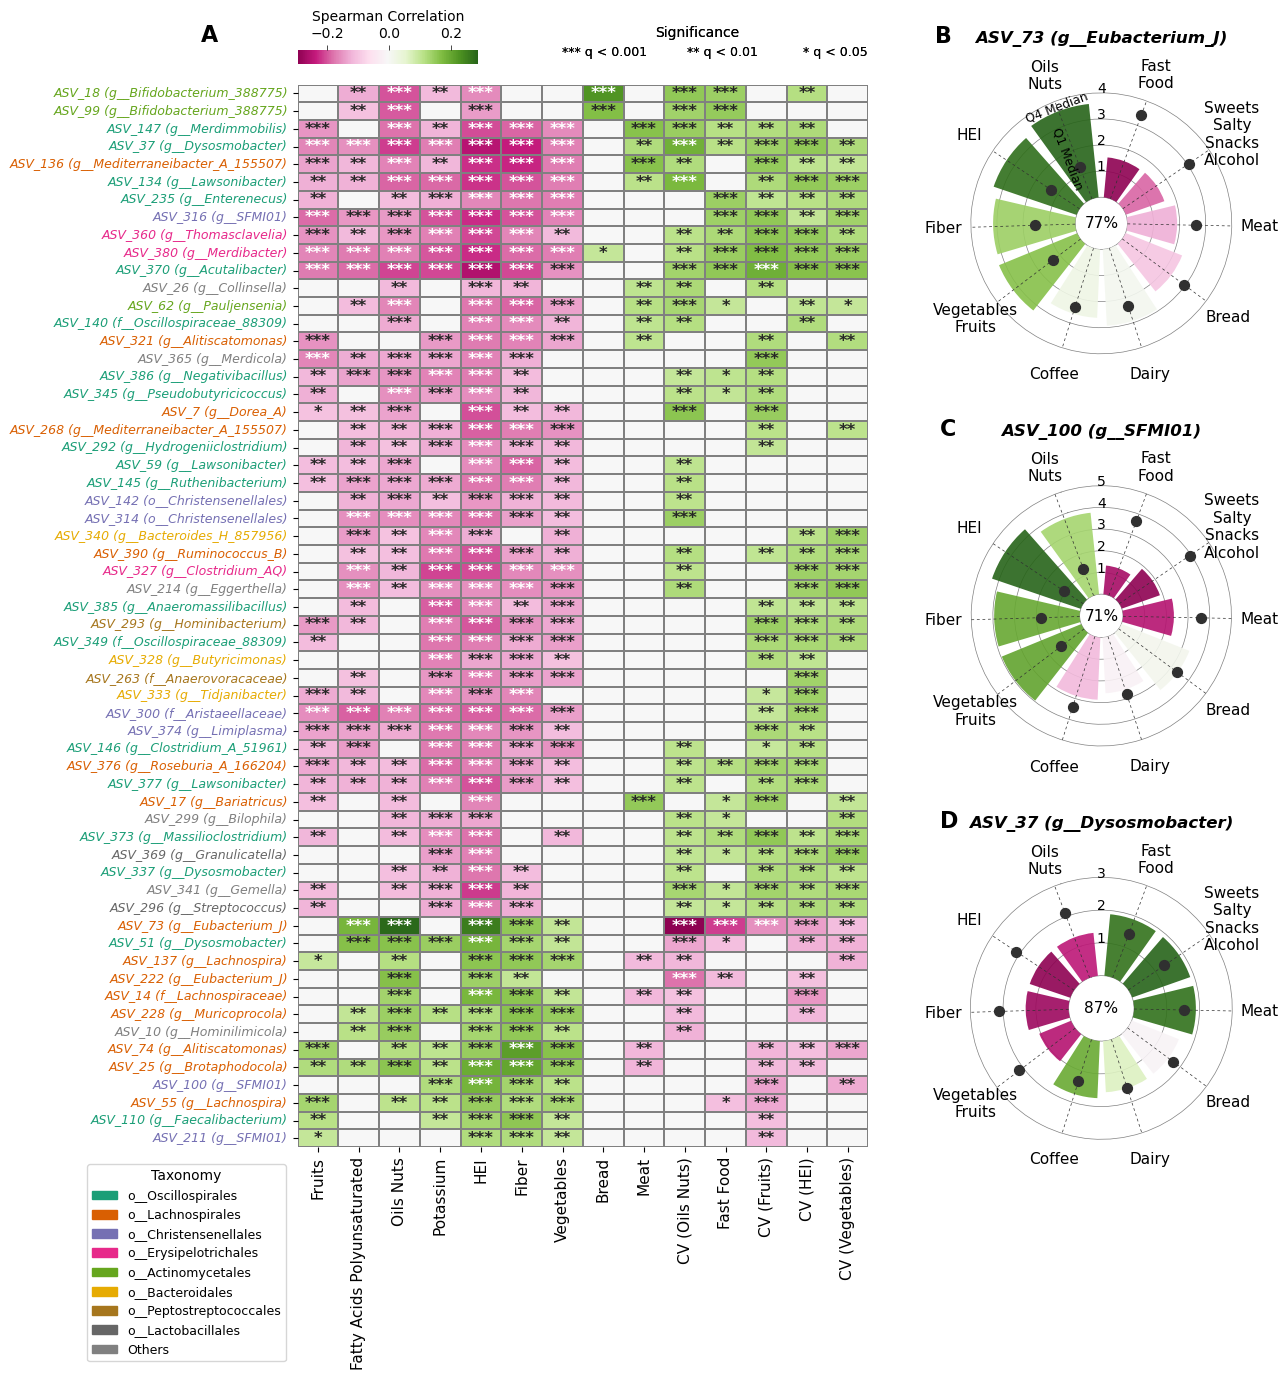

In [15]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(
    figsize=(13, 13.8),
)

gs = GridSpec(
    nrows=5,
    ncols=2,
    figure=fig,
    height_ratios=[1, 0.15, 1, 0.15, 1],
    width_ratios=[1.4, 1],
    wspace=0.06,
)

ax1 = fig.add_subplot(gs[0, 1], polar=True)
ax2 = fig.add_subplot(gs[2, 1], polar=True)
ax3 = fig.add_subplot(gs[4, 1], polar=True)

ax4 = fig.add_subplot(gs[:, 0])

cmap_radial = plt.cm.PiYG  # plt.cm.coolwarm_r #plt.cm.RdYlGn #

polar_plots_variables = [
    "oils_nuts_fg_eaten",
    "HEI",
    "fiber_eaten",
    "vegetables_fruits",
    "coffee_fg_eaten",
    "dairy_fg_eaten",
    "bread_fg_eaten",
    "meat_fg_eaten",
    "sweets_salty_snacks_alcohol",
    "fast_food_fg_eaten",
]


# bac_name_string = "Eubacterium_J plexicaudatum"
bac_name_string = "7dfa96abfa7484bb6c9cfa90dc9b606f"
print(otuID_taxonomy[otuID_taxonomy.index == bac_name_string]["Taxon"].values[0])
bac_quartile_medians_df = summarize_microbe_foodvar_relationship(
    transformed_counts_data, meta, polar_plots_variables, bac_name_string
)
create_polar_plot(
    bac_quartile_medians_df,
    ax1,
    prevalence,
    cmap=cmap_radial,
    paneltext="B",
    paneltext_pos=(-0.1, 1.15),
    taxon_type="ASV",
)

# bac_name_string = "Butyribacter intestini"
bac_name_string = (
    "e91f1c5b67ffecb5ca3ca3b393a50f00"  # "1243750138937650754b619370565800"
)
print(otuID_taxonomy[otuID_taxonomy.index == bac_name_string]["Taxon"].values[0])
bac_quartile_medians_df = summarize_microbe_foodvar_relationship(
    transformed_counts_data, meta, polar_plots_variables, bac_name_string
)
create_polar_plot(
    bac_quartile_medians_df,
    ax2,
    prevalence,
    cmap=cmap_radial,
    show_medians_text=False,
    paneltext="C",
    paneltext_pos=(-0.08, 1.15),
    taxon_type="ASV",
)

# bac_name_string = "Dysosmobacter welbionis"
bac_name_string = "c82032c40c98975f71892e4be561c87a"
print(otuID_taxonomy[otuID_taxonomy.index == bac_name_string]["Taxon"].values[0])
bac_quartile_medians_df = summarize_microbe_foodvar_relationship(
    transformed_counts_data, meta, polar_plots_variables, bac_name_string
)
create_polar_plot(
    bac_quartile_medians_df,
    ax3,
    prevalence,
    cmap=cmap_radial,
    show_medians_text=False,
    paneltext="D",
    paneltext_pos=(-0.08, 1.15),
    taxon_type="ASV",
)

draw_heatmap_from_clustermap_data(
    ax4,
    ordered_corr_df,
    ordered_annot_matrix,
    ancestry_colour_mapping,
    ancestor_mapping,
    legend_patches,
    cmap=cmap_radial,
    paneltext="A",
    paneltext_pos=(-0.17, 1.04),
)


ax4.text(-0.17, -0.14, " ", fontsize=16, fontweight="bold", transform=ax4.transAxes)
ax4.set_xlabel("")

# sns.despine()
# plt.tight_layout()
plt.savefig("../../figures/taxa_correlation_analysis/Fig3.png", bbox_inches="tight")

plt.show()